# Grad-CAM Visualisation
Generates publication-quality Grad-CAM figures for the explainability section.

**Figures produced:**
1. Side-by-side: Original patch → Heatmap → Overlay (dyslexic + normal)
2. Grid of top dyslexic patches with overlays
3. Grid of top normal patches with overlays

In [10]:
import os
from pathlib import Path
# Always run from project root so relative paths work
os.chdir(Path(__file__).parent if "__file__" in dir() else Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
import sys
sys.path.insert(0, str(Path.cwd()))

import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from PIL import Image

from utils.predict import load_model
from utils.preprocess import transform
from utils.gradcam import generate_gradcam_visualization
import config

OUT_DIR  = Path('figures')
OUT_DIR.mkdir(exist_ok=True)
DATA_DIR = Path(config.DATA_DIR)

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

device = torch.device(config.DEVICE)
print('Loading model...')
model = load_model()
model.eval()
print(f'Model loaded on {device}')

Loading model...
Model loaded on cuda


In [11]:
# Helper: score and get Grad-CAM for a single image file
def analyse_patch(img_path, threshold=0.5):
    pil  = Image.open(img_path).convert('RGB')
    arr  = np.array(pil)
    t    = transform(pil).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = model(t).item()
    cam, overlay = generate_gradcam_visualization(model, arr, t, device)
    return pil, arr, cam, overlay, prob

# Sample images
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg')

def get_paths(cls, n=4):
    paths = []
    searched = []
    for split in ['test', 'val', 'train']:
        p = DATA_DIR / split / cls
        searched.append(p)
        if p.exists():
            split_paths = [x for x in p.iterdir() if x.is_file() and x.suffix.lower() in IMAGE_EXTENSIONS]
            paths.extend(split_paths[:n * 2])
    if not paths:
        print(f'No images found for {cls}. Searched:')
        for p in searched:
            print(f'  - {p}')
    random.seed(7)
    return random.sample(paths, min(n, len(paths)))

print(f'Selecting sample images from {DATA_DIR}...')
dys_paths = get_paths('dyslexic', 4)
nor_paths = get_paths('normal',   4)
print(f'Dyslexic: {len(dys_paths)} | Normal: {len(nor_paths)}')

Selecting sample images from c:\Users\ASUS\Desktop\Early-screening-of-dyslexia-\notebooks\..\data...
Dyslexic: 4 | Normal: 4


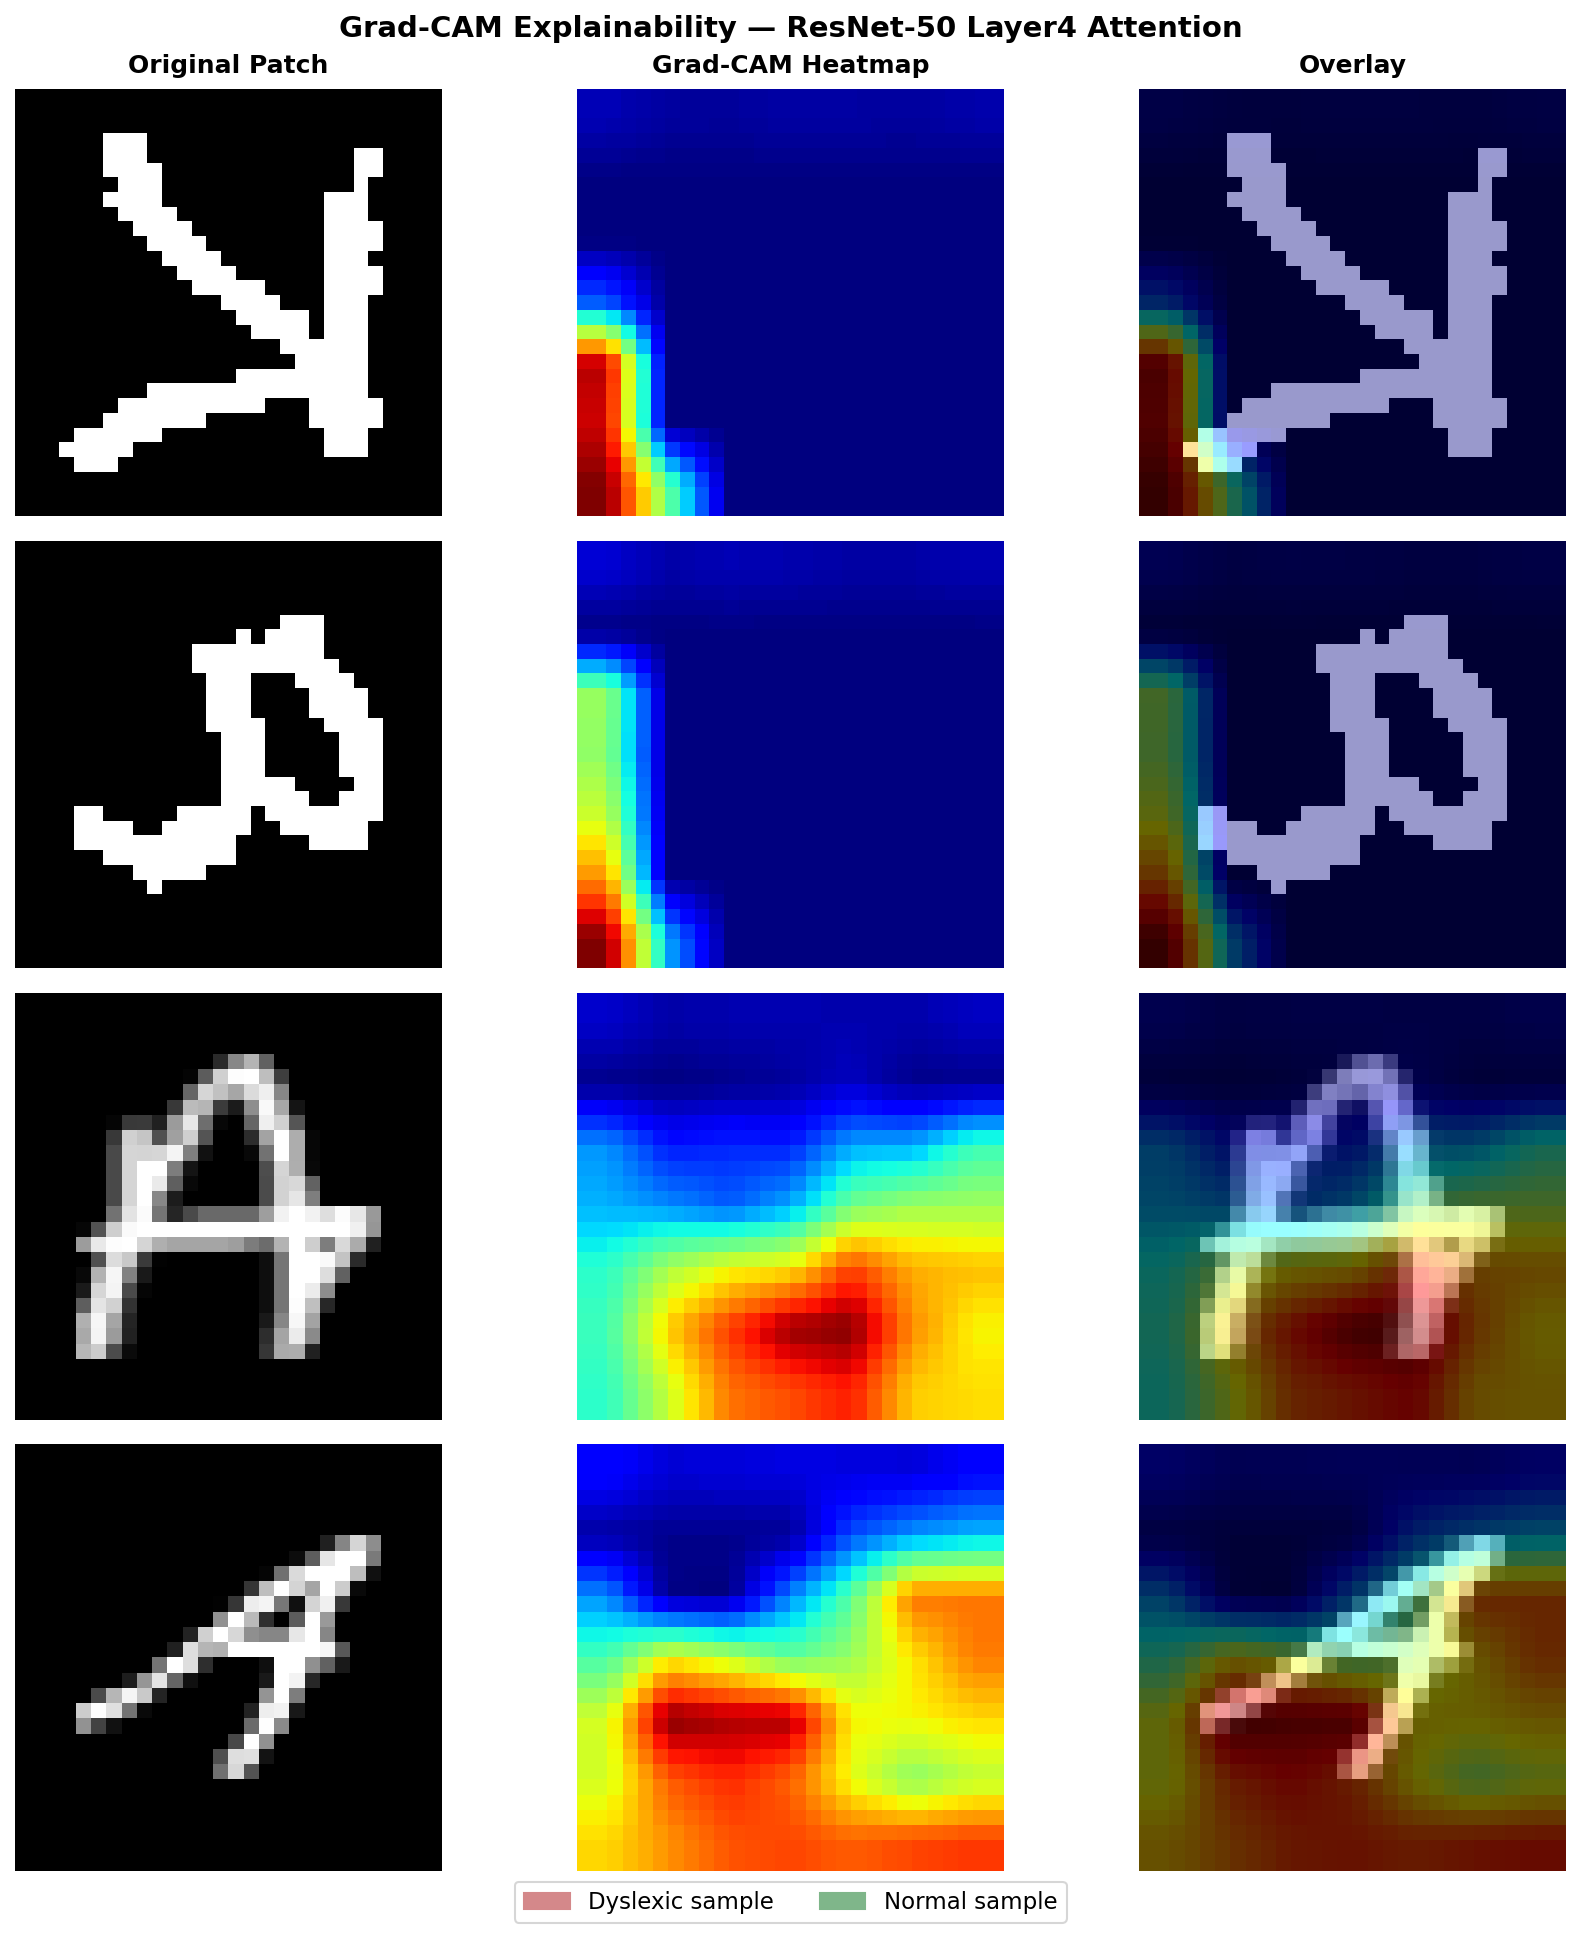

Saved fig8_gradcam_panel.png


In [12]:
# Figure — Main Grad-CAM panel (2 dyslexic + 2 normal, 3 cols each: original | heatmap | overlay)
n_show   = 2
n_cols   = 3
n_rows   = n_show * 2   # dyslexic rows + normal rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 3.2))
fig.suptitle('Grad-CAM Explainability — ResNet-50 Layer4 Attention',
             fontsize=14, fontweight='bold')

col_titles = ['Original Patch', 'Grad-CAM Heatmap', 'Overlay']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold', pad=8)

row = 0
for paths, cls_label, border_color in [
    (dys_paths[:n_show], 'Dyslexic', '#D4888A'),
    (nor_paths[:n_show], 'Normal',   '#7FB68A'),
]:
    for path in paths:
        try:
            pil, arr, cam, overlay, prob = analyse_patch(path)
        except Exception as e:
            print(f'Skipping {path.name}: {e}')
            row += 1; continue

        import cv2
        if cam is not None:
            cam_resized = cv2.resize(cam, (arr.shape[1], arr.shape[0]))
            heatmap_img = plt.cm.jet(cam_resized)[:, :, :3]   # RGB heatmap
        else:
            heatmap_img = np.zeros_like(arr)

        for col, img_data in enumerate([arr, heatmap_img, overlay]):
            ax = axes[row, col]
            ax.imshow(img_data)
            ax.axis('off')
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(2.5)
                spine.set_visible(True)

        axes[row, 0].set_ylabel(
            f'{cls_label}\nP={prob:.2f}',
            color=border_color, fontsize=10, fontweight='bold', rotation=0,
            labelpad=55, va='center'
        )
        row += 1

# Legend
legend_patches = [
    mpatches.Patch(color='#D4888A', label='Dyslexic sample'),
    mpatches.Patch(color='#7FB68A', label='Normal sample'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig8_gradcam_panel.png')
plt.show()
print('Saved fig8_gradcam_panel.png')

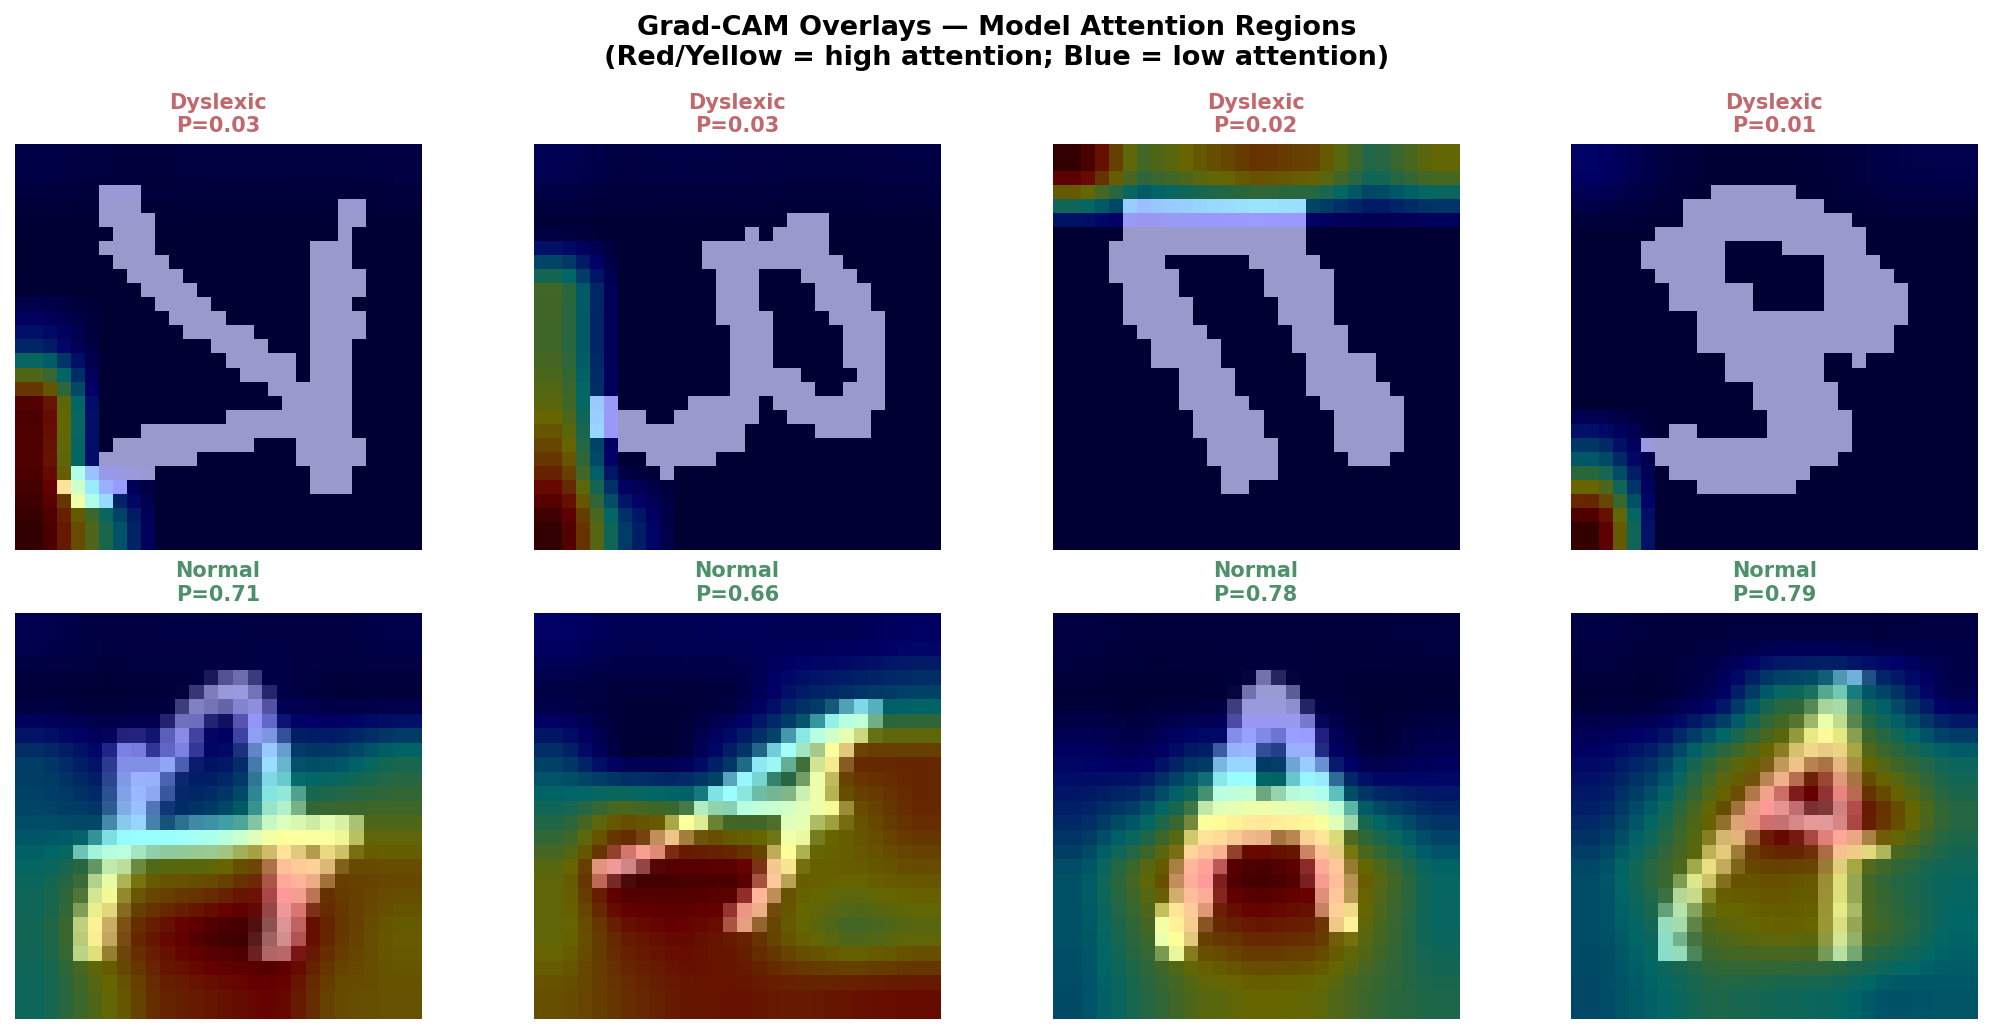

Saved fig9_gradcam_grid.png


In [13]:
# Figure — Extended overlay grid (4 dyslexic + 4 normal overlays only)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Grad-CAM Overlays — Model Attention Regions\n'
             '(Red/Yellow = high attention; Blue = low attention)',
             fontsize=13, fontweight='bold')

for col, path in enumerate(dys_paths[:4]):
    try:
        _, arr, _, overlay, prob = analyse_patch(path)
        axes[0, col].imshow(overlay if overlay is not None else arr)
        axes[0, col].set_title(f'Dyslexic\nP={prob:.2f}',
                               color='#C0686B', fontsize=10, fontweight='bold')
    except Exception as e:
        axes[0, col].text(0.5, 0.5, str(e), ha='center', va='center',
                          transform=axes[0, col].transAxes)
    axes[0, col].axis('off')

for col, path in enumerate(nor_paths[:4]):
    try:
        _, arr, _, overlay, prob = analyse_patch(path)
        axes[1, col].imshow(overlay if overlay is not None else arr)
        axes[1, col].set_title(f'Normal\nP={prob:.2f}',
                               color='#4E906A', fontsize=10, fontweight='bold')
    except Exception as e:
        axes[1, col].text(0.5, 0.5, str(e), ha='center', va='center',
                          transform=axes[1, col].transAxes)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig9_gradcam_grid.png')
plt.show()
print('Saved fig9_gradcam_grid.png')

In [14]:
print('\nAll Grad-CAM figures saved to:', OUT_DIR.resolve())
print('\nUsage in paper:')
print('  fig8_gradcam_panel.png  → main explainability figure')
print('  fig9_gradcam_grid.png   → supplementary figure')


All Grad-CAM figures saved to: C:\Users\ASUS\Desktop\Early-screening-of-dyslexia-\figures

Usage in paper:
  fig8_gradcam_panel.png  → main explainability figure
  fig9_gradcam_grid.png   → supplementary figure
